# Quanto Options

A **quanto** (quantity-adjusted) option pays in domestic currency an amount determined by a foreign-currency asset price, with the exchange rate implicitly fixed at 1.  This eliminates FX risk for the holder while preserving exposure to the foreign underlying.

## Quanto-adjusted Forward

Under the domestic risk-neutral measure, the foreign asset's drift is adjusted by the quanto correction:

$$F_{\text{adj}} = S \cdot \exp\!\left(\left(r_{d} - q_f - \rho\,\sigma_S\,\sigma_X\right) T\right)$$

where
- $r_d$ = domestic risk-free rate
- $q_f$ = dividend yield of the foreign asset
- $\rho$ = correlation between asset and FX log-returns
- $\sigma_S$ = foreign asset volatility
- $\sigma_X$ = FX rate volatility

Once the adjusted forward is known, the option price is a standard BSM formula:

$$\text{Quanto Call} = e^{-r_d T} \cdot \text{BSCall}(F_{\text{adj}}, K, T, \sigma_S)$$

## Notebook Sections
1. Quanto forward: formula check and rho / sigma_X sensitivity
2. Put-call parity verification
3. rho effect on call and put prices
4. Comparison with plain BSM (rho=0 case)
5. Spot sweep: quanto vs. standard European

**Reference**: Reiner, E. (1992). Quanto mechanics. *Risk*, 5(3), 59-63.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import math

import foureng as fe
from foureng.analytics.bsm_quanto import bsm_quanto_forward, bsm_quanto_option

plt.rcParams.update({'figure.dpi': 110, 'axes.grid': True, 'grid.alpha': 0.35})
print(f'foureng {fe.__version__}')

foureng 0.5.0


## 1. Quanto-adjusted Forward

### Formula Check

With $\rho = 0$, the quanto adjustment vanishes and the adjusted forward equals the plain forward $S e^{(r_d - q_f)T}$ (not the foreign forward -- no foreign rate enters because the quanto locks the exchange rate).

In [2]:
# Base parameters
S       = 100.0   # foreign spot
K       = 105.0   # strike (foreign currency)
r_dom   = 0.05    # domestic rate
r_for   = 0.03    # foreign rate (not used in adjustment itself)
q_for   = 0.02    # foreign dividend yield
sigma_S = 0.20    # foreign asset vol
sigma_X = 0.10    # FX vol
T       = 1.0     # 1 year

# rho=0 -> plain forward
F_plain = S * math.exp((r_dom - q_for) * T)
F_adj_0 = bsm_quanto_forward(S, r_dom, r_for, q_for, 0.0, sigma_S, sigma_X, T)
print(f'Plain forward (rho=0):    {F_plain:.6f}')
print(f'Quanto forward (rho=0):   {F_adj_0:.6f}')
print(f'Match (should be True):   {abs(F_plain - F_adj_0) < 1e-10}')

# Negative rho -> higher forward (negative quanto adjustment increases drift)
F_neg = bsm_quanto_forward(S, r_dom, r_for, q_for, -0.5, sigma_S, sigma_X, T)
F_pos = bsm_quanto_forward(S, r_dom, r_for, q_for,  0.5, sigma_S, sigma_X, T)
print(f'\nQuanto forward (rho=-0.5): {F_neg:.6f}  > {F_adj_0:.6f} (rho=0)')
print(f'Quanto forward (rho=+0.5): {F_pos:.6f}  < {F_adj_0:.6f} (rho=0)')

Plain forward (rho=0):    103.045453
Quanto forward (rho=0):   103.045453
Match (should be True):   True

Quanto forward (rho=-0.5): 104.081077  > 103.045453 (rho=0)
Quanto forward (rho=+0.5): 102.020134  < 103.045453 (rho=0)


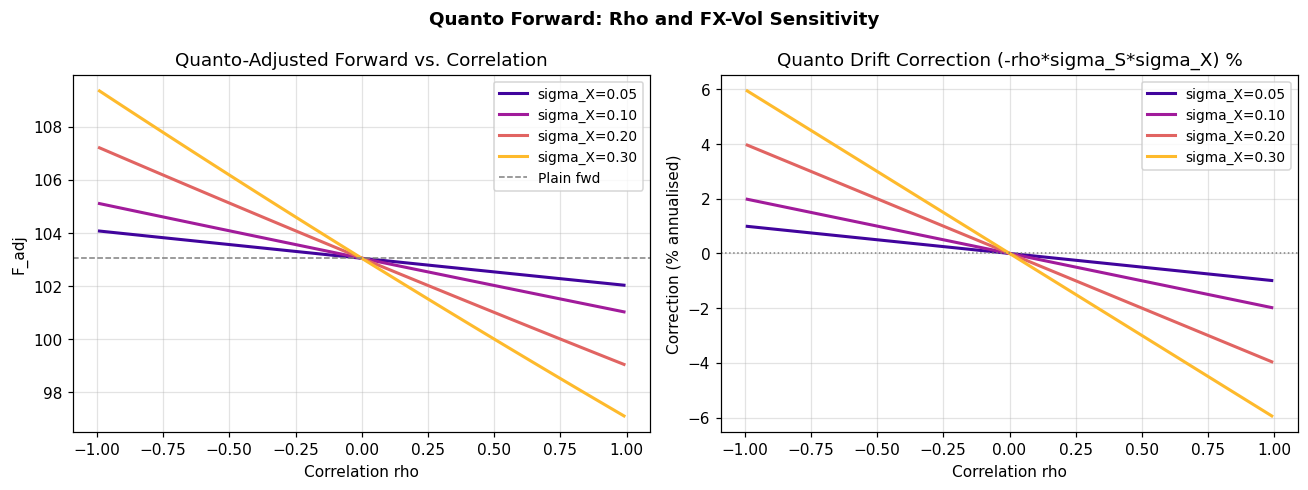

In [3]:
# Sensitivity to rho and sigma_X
rho_arr    = np.linspace(-0.99, 0.99, 100)
sigma_X_arr = [0.05, 0.10, 0.20, 0.30]

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
colors = plt.cm.plasma(np.linspace(0.1, 0.85, len(sigma_X_arr)))

for sx, c in zip(sigma_X_arr, colors):
    F_arr = np.array([bsm_quanto_forward(S, r_dom, r_for, q_for, rho, sigma_S, sx, T)
                      for rho in rho_arr])
    axes[0].plot(rho_arr, F_arr, color=c, lw=2, label=f'sigma_X={sx:.2f}')

axes[0].axhline(F_plain, ls='--', color='gray', lw=1, label='Plain fwd')
axes[0].set(title='Quanto-Adjusted Forward vs. Correlation',
            xlabel='Correlation rho', ylabel='F_adj')
axes[0].legend(fontsize=9)

# Quanto correction = rho * sigma_S * sigma_X (in drift)
for sx, c in zip(sigma_X_arr, colors):
    correction = -rho_arr * sigma_S * sx   # added to drift
    axes[1].plot(rho_arr, correction * 100, color=c, lw=2, label=f'sigma_X={sx:.2f}')

axes[1].axhline(0, ls=':', color='gray', lw=1)
axes[1].set(title='Quanto Drift Correction (-rho*sigma_S*sigma_X) %',
            xlabel='Correlation rho', ylabel='Correction (% annualised)')
axes[1].legend(fontsize=9)

fig.suptitle('Quanto Forward: Rho and FX-Vol Sensitivity', fontweight='bold')
plt.tight_layout()
plt.show()

## 2. Put-Call Parity

For a quanto option:
$$C - P = e^{-r_d T}(F_{\text{adj}} - K)$$

This differs from the standard PCP because the forward is the quanto-adjusted one.

In [4]:
rho   = -0.3
F_adj = bsm_quanto_forward(S, r_dom, r_for, q_for, rho, sigma_S, sigma_X, T)
disc  = math.exp(-r_dom * T)

print('Put-Call Parity: C - P = disc * (F_adj - K)')
print(f'{"K":>8}  {"Call":>10}  {"Put":>10}  {"C-P":>10}  {"disc*(F-K)":>12}  {"Error":>10}')
for K_test in [80, 90, 100, 105, 110, 120]:
    C = bsm_quanto_option(S, K_test, r_dom, r_for, q_for, rho, sigma_S, sigma_X, T, cp=1)
    P = bsm_quanto_option(S, K_test, r_dom, r_for, q_for, rho, sigma_S, sigma_X, T, cp=-1)
    parity = disc * (F_adj - K_test)
    err = abs((C - P) - parity)
    print(f'{K_test:>8}  {C:>10.5f}  {P:>10.5f}  {C-P:>10.5f}  {parity:>12.5f}  {err:>10.2e}')

Put-Call Parity: C - P = disc * (F_adj - K)
       K        Call         Put         C-P    disc*(F-K)       Error
      80    23.30465     0.79325    22.51140      22.51140    3.55e-15
      90    15.58722     2.58811    12.99911      12.99911    7.11e-15
     100     9.58359     6.09678     3.48681       3.48681    6.66e-15
     105     7.28682     8.55615    -1.26934      -1.26934    2.22e-16
     110     5.43411    11.45960    -6.02548      -6.02548    7.11e-15
     120     2.86453    18.40231   -15.53778     -15.53778    8.88e-15


## 3. Effect of Correlation on Option Prices

Negative correlation between the foreign asset and the FX rate is common (e.g., EUR-USD often negatively correlated with European equity). The quanto correction increases the effective forward, making calls more expensive and puts cheaper.

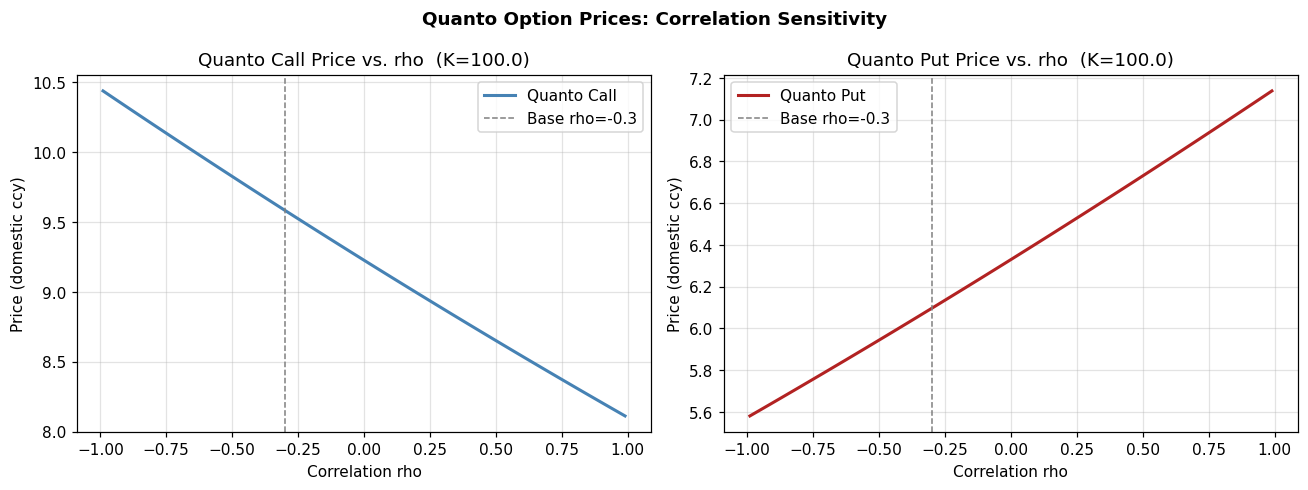

Base case (rho=-0.3): call=9.5956,  put=6.0891
No correction (rho~0): call=9.2387, put=6.3222


In [5]:
rho_arr = np.linspace(-0.99, 0.99, 100)
K_atm   = 100.0  # approximately ATM

calls = np.array([bsm_quanto_option(S, K_atm, r_dom, r_for, q_for, rho, sigma_S, sigma_X, T, cp=1)
                  for rho in rho_arr])
puts  = np.array([bsm_quanto_option(S, K_atm, r_dom, r_for, q_for, rho, sigma_S, sigma_X, T, cp=-1)
                  for rho in rho_arr])

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

axes[0].plot(rho_arr, calls, lw=2, color='steelblue', label='Quanto Call')
axes[0].axvline(-0.3, ls='--', color='gray', lw=1, label='Base rho=-0.3')
axes[0].set(title=f'Quanto Call Price vs. rho  (K={K_atm})', 
            xlabel='Correlation rho', ylabel='Price (domestic ccy)')
axes[0].legend()

axes[1].plot(rho_arr, puts, lw=2, color='firebrick', label='Quanto Put')
axes[1].axvline(-0.3, ls='--', color='gray', lw=1, label='Base rho=-0.3')
axes[1].set(title=f'Quanto Put Price vs. rho  (K={K_atm})',
            xlabel='Correlation rho', ylabel='Price (domestic ccy)')
axes[1].legend()

fig.suptitle('Quanto Option Prices: Correlation Sensitivity', fontweight='bold')
plt.tight_layout()
plt.show()

idx_neg03 = int(np.argmin(np.abs(rho_arr + 0.3)))
idx_zero  = int(np.argmin(np.abs(rho_arr)))
print(f'Base case (rho=-0.3): call={calls[idx_neg03]:.4f},  put={puts[idx_neg03]:.4f}')
print(f'No correction (rho~0): call={calls[idx_zero]:.4f}, put={puts[idx_zero]:.4f}')

## 4. Quanto vs. Standard European (rho=0 limit)

When $\rho = 0$, the quanto call should equal a standard BSM call with forward $F = S e^{(r_d - q_f)T}$ and domestic discount.

When $\rho \ne 0$ the quanto differs from a standard option in two ways:
1. The forward is shifted by $-\rho\sigma_S\sigma_X T$
2. FX volatility does NOT enter the BSM formula -- it only affects the drift, not the variance

rho=0 quanto call: 6.986920
BSM call (dom fwd): 6.986920
Match: True


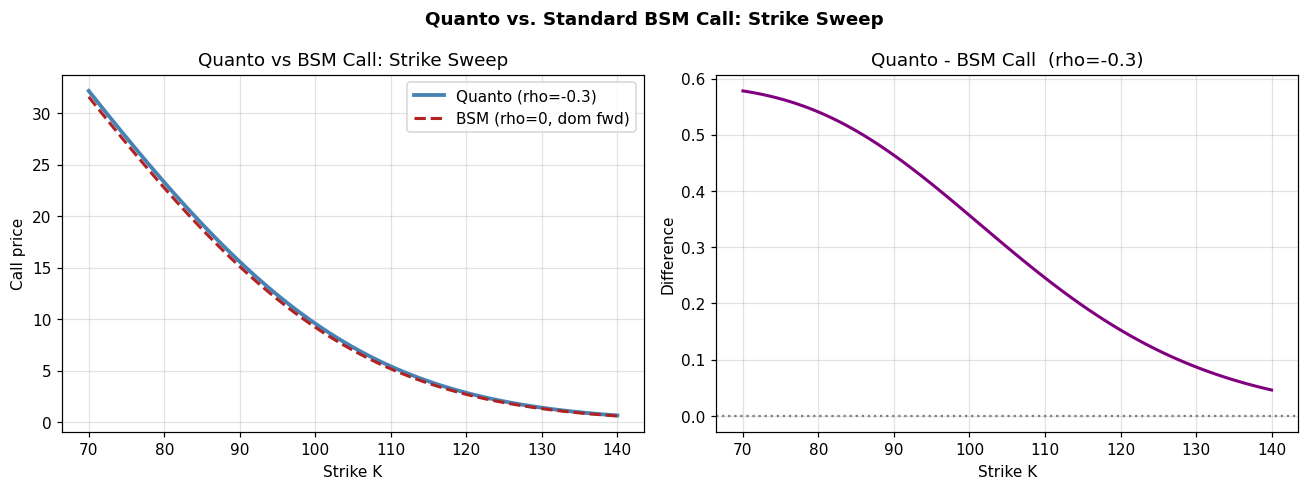

In [6]:
from scipy.stats import norm as _norm

def bsm_call_fwd(F, K, r, T, sigma):
    """Standard BSM call with given forward F."""
    disc = math.exp(-r * T)
    sqT  = math.sqrt(T)
    d1 = (math.log(F / K) + 0.5 * sigma**2 * T) / (sigma * sqT)
    d2 = d1 - sigma * sqT
    return disc * (F * _norm.cdf(d1) - K * _norm.cdf(d2))

# rho=0: quanto = standard with domestic forward
F_dom = S * math.exp((r_dom - q_for) * T)   # domestic forward
bsm_call = bsm_call_fwd(F_dom, K, r_dom, T, sigma_S)
qnt_call  = bsm_quanto_option(S, K, r_dom, r_for, q_for, 0.0, sigma_S, sigma_X, T, cp=1)
print(f'rho=0 quanto call: {qnt_call:.6f}')
print(f'BSM call (dom fwd): {bsm_call:.6f}')
print(f'Match: {abs(qnt_call - bsm_call) < 1e-10}')

# Strike sweep: quanto (rho=-0.3) vs standard BSM
K_arr = np.linspace(70, 140, 80)
rho_base = -0.3

qnt_calls = np.array([bsm_quanto_option(S, Kk, r_dom, r_for, q_for, rho_base, sigma_S, sigma_X, T, 1)
                       for Kk in K_arr])
bsm_calls = np.array([bsm_call_fwd(F_dom, Kk, r_dom, T, sigma_S) for Kk in K_arr])

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

axes[0].plot(K_arr, qnt_calls, lw=2.5, color='steelblue', label=f'Quanto (rho={rho_base})')
axes[0].plot(K_arr, bsm_calls, lw=2, ls='--', color='firebrick', label='BSM (rho=0, dom fwd)')
axes[0].set(title='Quanto vs BSM Call: Strike Sweep', xlabel='Strike K', ylabel='Call price')
axes[0].legend()

axes[1].plot(K_arr, (qnt_calls - bsm_calls), lw=2, color='purple')
axes[1].axhline(0, ls=':', color='gray')
axes[1].set(title=f'Quanto - BSM Call  (rho={rho_base})', xlabel='Strike K', ylabel='Difference')

fig.suptitle('Quanto vs. Standard BSM Call: Strike Sweep', fontweight='bold')
plt.tight_layout()
plt.show()

## 5. Spot Sweep: Quanto vs. Standard European

Varying the foreign spot while fixing the strike, we compare quanto call prices under different correlations.

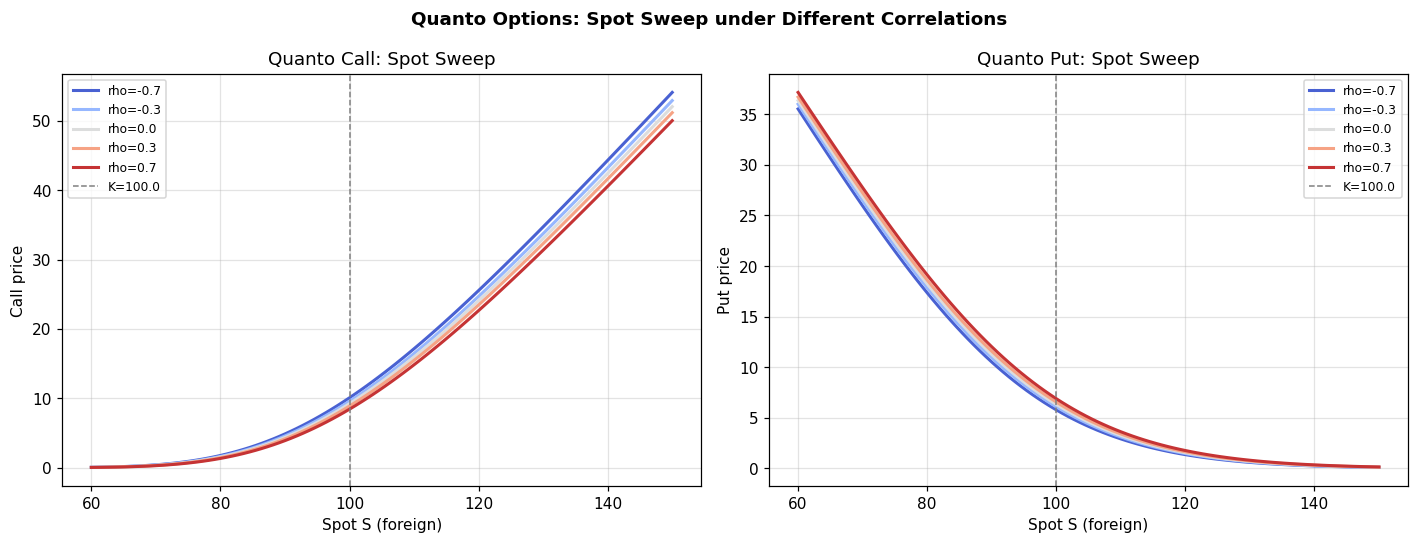

In [7]:
S_arr = np.linspace(60, 150, 100)
K_fix = 100.0
rhos  = [-0.7, -0.3, 0.0, 0.3, 0.7]

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
colors = plt.cm.coolwarm(np.linspace(0.05, 0.95, len(rhos)))

for rho_v, c in zip(rhos, colors):
    calls = np.array([bsm_quanto_option(Sv, K_fix, r_dom, r_for, q_for, rho_v, sigma_S, sigma_X, T, 1)
                      for Sv in S_arr])
    axes[0].plot(S_arr, calls, color=c, lw=2, label=f'rho={rho_v:.1f}')
    puts  = np.array([bsm_quanto_option(Sv, K_fix, r_dom, r_for, q_for, rho_v, sigma_S, sigma_X, T, -1)
                      for Sv in S_arr])
    axes[1].plot(S_arr, puts, color=c, lw=2, label=f'rho={rho_v:.1f}')

axes[0].axvline(K_fix, ls='--', color='gray', lw=1, label=f'K={K_fix}')
axes[0].set(title='Quanto Call: Spot Sweep', xlabel='Spot S (foreign)', ylabel='Call price')
axes[0].legend(fontsize=8)

axes[1].axvline(K_fix, ls='--', color='gray', lw=1, label=f'K={K_fix}')
axes[1].set(title='Quanto Put: Spot Sweep', xlabel='Spot S (foreign)', ylabel='Put price')
axes[1].legend(fontsize=8)

fig.suptitle('Quanto Options: Spot Sweep under Different Correlations', fontweight='bold')
plt.tight_layout()
plt.show()

In [8]:
# Summary table
print('Quanto Call/Put Prices for S=100, K=100, T=1y')
print(f'{"rho":>6}  {"F_adj":>10}  {"Call":>10}  {"Put":>10}  {"C-P":>10}')
for rho_v in [-0.7, -0.5, -0.3, 0.0, 0.3, 0.5, 0.7]:
    F_a = bsm_quanto_forward(100, r_dom, r_for, q_for, rho_v, sigma_S, sigma_X, T)
    C   = bsm_quanto_option(100, 100.0, r_dom, r_for, q_for, rho_v, sigma_S, sigma_X, T, 1)
    P   = bsm_quanto_option(100, 100.0, r_dom, r_for, q_for, rho_v, sigma_S, sigma_X, T, -1)
    print(f'{rho_v:>6.1f}  {F_a:>10.4f}  {C:>10.4f}  {P:>10.4f}  {C-P:>10.4f}')

# Show QuantoOption product dataclass
print('\nQuantoOption dataclass example:')
q = fe.QuantoOption(S=100.0, K=105.0, T=1.0, r_dom=0.05, r_for=0.03, q_for=0.02,
                    rho=-0.3, sigma_S=0.20, sigma_X=0.10, cp=1)
print(q)

Quanto Call/Put Prices for S=100, K=100, T=1y
   rho       F_adj        Call         Put         C-P
  -0.7    104.4982     10.0730      5.7942      4.2789
  -0.5    104.0811      9.8263      5.9443      3.8820
  -0.3    103.6656      9.5836      6.0968      3.4868
   0.0    103.0455      9.2270      6.3301      2.8969
   0.3    102.4290      8.8794      6.5688      2.3106
   0.5    102.0201      8.6525      6.7309      1.9216
   0.7    101.6129      8.4296      6.8954      1.5342

QuantoOption dataclass example:
QuantoOption(S=100.0, K=105.0, T=1.0, r_dom=0.05, r_for=0.03, q_for=0.02, rho=-0.3, sigma_S=0.2, sigma_X=0.1, cp=1)
